In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [3]:
df = pd.read_csv(r"D:\nguyen binh\shopee_reviews.csv")
df.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11608\238766778.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\nguyen binh\shopee_reviews.csv")


,label,text
0,5,Looks ok. Not like so durable. Will hv to use ...
1,5,"Tried, the current can be very powerful depend..."
2,5,Item received after a week. Looks smaller than...
3,5,Thanks!!! Works as describe no complaints. Not...
4,5,Fast delivery considering it’s from overseas a...


###### df = df.dropna(subset=['label', 'text'])
df.info()

In [7]:
df = df.rename(columns={
    'label': 'rating',
    'text': 'review'
})

In [9]:
print(df.isnull().sum())

rating    0
review    0
dtype: int64


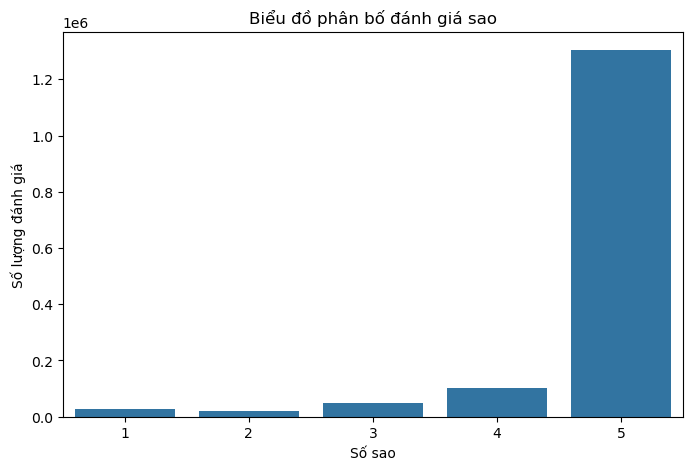

In [89]:
plt.figure(figsize=(8,5))

sns.countplot(x='rating', data=df)

plt.title("Biểu đồ phân bố đánh giá sao")
plt.xlabel("Số sao")
plt.ylabel("Số lượng đánh giá")

plt.show()

In [49]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df = df.dropna(subset=['rating'])
df['rating'] = df['rating'].astype(int)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11608\2401585875.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['rating'] = df['rating'].astype(int)


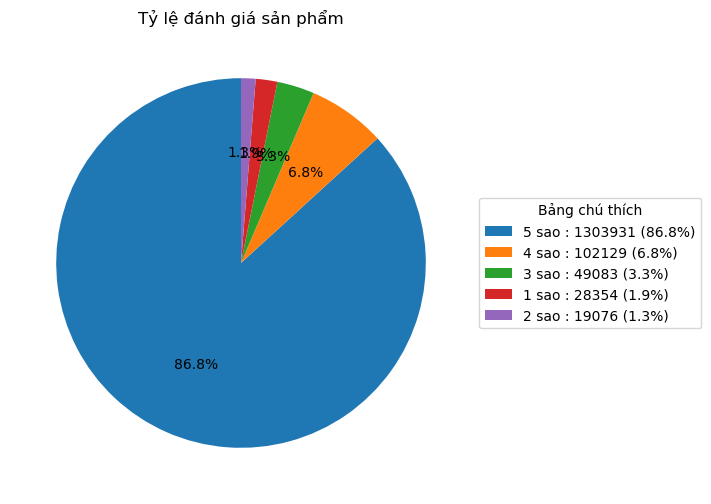

In [77]:
rating_counts = df['rating'].value_counts()

# tính phần trăm
percentages = rating_counts / rating_counts.sum() * 100

legend_labels = [
    f"{rating} sao : {count} ({percent:.1f}%)"
    for rating, count, percent in zip(rating_counts.index, rating_counts, percentages)
]

plt.figure(figsize=(7,6))

plt.pie(
    rating_counts,
    startangle=90,
    autopct='%1.1f%%'
)

plt.title("Tỷ lệ đánh giá sản phẩm")
plt.legend(legend_labels, title="Bảng chú thích", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

In [93]:
df['review_length'] = df['review'].apply(len)

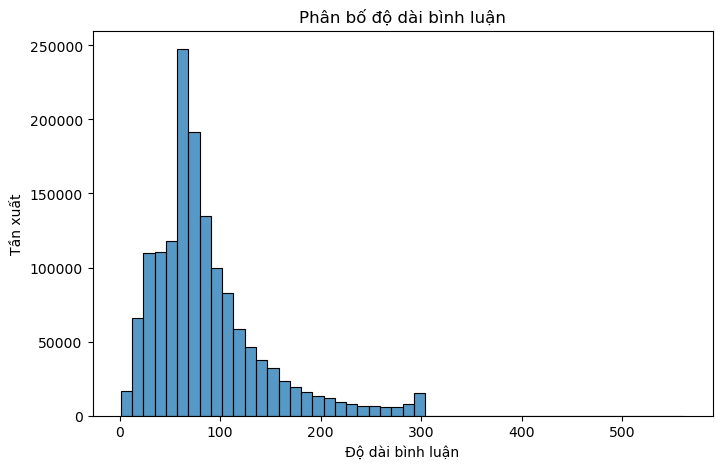

In [94]:
plt.figure(figsize=(8,5))

sns.histplot(df['review_length'], bins=50)

plt.title("Phân bố độ dài bình luận")
plt.xlabel("Độ dài bình luận")
plt.ylabel("Tần xuất")

plt.show()

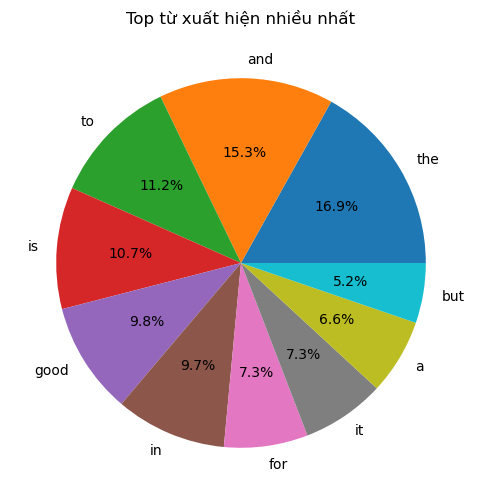

In [102]:
top10 = words_df.head(10)

plt.figure(figsize=(6,6))

plt.pie(
    top10['Số lần'],
    labels=top10['Từ'],
    autopct='%1.1f%%'
)

plt.title("Top từ xuất hiện nhiều nhất")

plt.show()

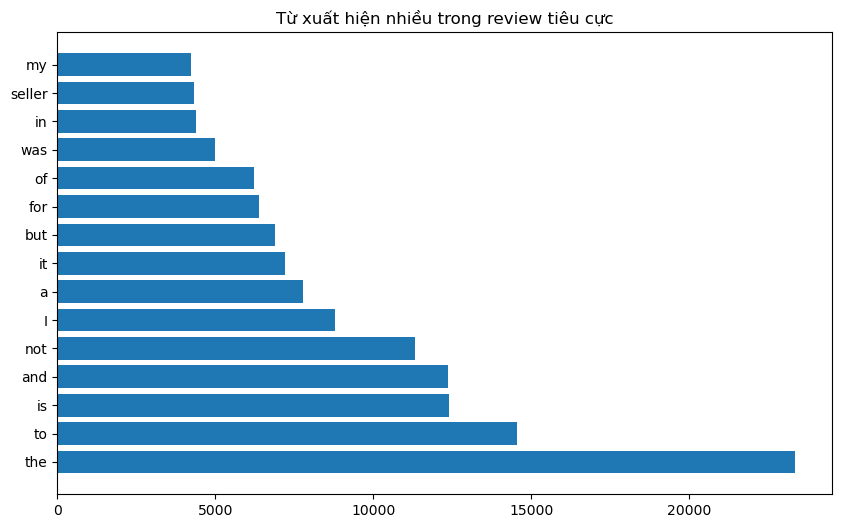

In [108]:
negative = df[df['rating'] == 1]

text = " ".join(negative['review'].astype(str))

words = text.split()

word_counts = Counter(words)

common_words = word_counts.most_common(15)

words_df = pd.DataFrame(common_words, columns=['Từ', 'Số lần'])

plt.figure(figsize=(10,6))

plt.barh(words_df['Từ'], words_df['Số lần'])

plt.title("Từ xuất hiện nhiều trong review tiêu cực")

plt.show()

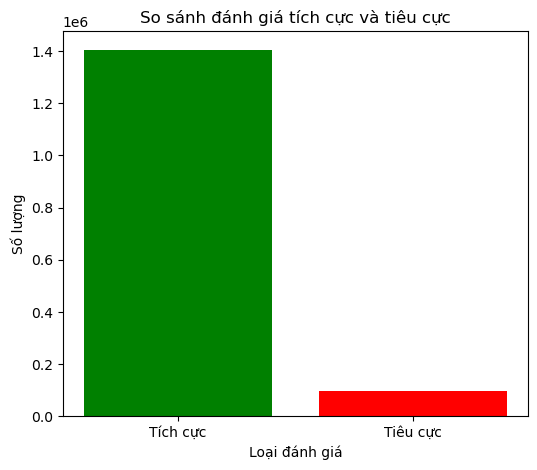

In [110]:
df['loai_danh_gia'] = df['rating'].apply(
    lambda x: "Tích cực" if x >= 4 else "Tiêu cực"
)

sentiment_counts = df['loai_danh_gia'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green','red'])

plt.title("So sánh đánh giá tích cực và tiêu cực")
plt.xlabel("Loại đánh giá")
plt.ylabel("Số lượng")

plt.show()